# AI Heat Resilience Hackathon — Pipeline v2
## Refinement Network with Inferno Colormap Fix

**What this does:**
- Uses frozen ThermalGen baseline predictions (Phase 1 already done)
- Applies inferno colormap to match ground truth format
- Trains a lightweight U-Net that uses RGB + ThermalGen + Weather + AlphaEarth
- Outputs 3-channel colormapped thermal predictions

**Run cells in order. Phase 1 is already done — skip straight to training.**

## Cell 1: Setup & Paths

In [1]:
import os, json, time
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms.v2 as v2
import torchvision.transforms.functional as TF
from torchvision.transforms.functional import to_pil_image
from PIL import Image
from pathlib import Path
from IPython.display import display, Image as IPImage

# Use GPU 1 (GPU 0 is busy)
os.environ['CUDA_VISIBLE_DEVICES'] = '1'
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Device: {device}')
if device == 'cuda':
    print(f'GPU: {torch.cuda.get_device_name(0)}')

# Paths
BASE = Path(os.path.expanduser('~/AI_Heat_Resilience_Hackathon_Resources/AI_Heat_Resilience_Hackathon_Resources'))
TGEN = BASE / 'ThermalGen'

TRAIN_RGB_DIR = TGEN / 'datasets_raw' / 'Train_2' / 'RGB'
TRAIN_THERMAL_DIR = TGEN / 'datasets_raw' / 'Train_2' / 'Thermal'
TEST_RGB_DIR = TGEN / 'datasets_raw' / 'Test_2' / 'RGB'

BASELINE_TRAIN = TGEN / 'baseline_predictions' / 'train'
BASELINE_TEST = TGEN / 'baseline_predictions' / 'test'

SPLIT_JSON = BASE / 'train_test_split.json'
WEATHER_JSON = BASE / 'Weather_data_and_code' / 'drone_and_weather_metadata.json'
EMBEDDING_DIR = BASE / 'Google AlphaEarth Embeddings code'

OUTPUT_DIR = TGEN / 'test_predictions_v2_nb'
CHECKPOINT_DIR = TGEN / 'refinement_checkpoints_v2_nb'
VIS_DIR = TGEN / 'visualizations_v2_nb'

os.makedirs(OUTPUT_DIR, exist_ok=True)
os.makedirs(CHECKPOINT_DIR, exist_ok=True)
os.makedirs(VIS_DIR, exist_ok=True)

# Verify Phase 1
n_train = len([f for f in os.listdir(BASELINE_TRAIN) if f.upper().endswith('.JPG')])
n_test = len([f for f in os.listdir(BASELINE_TEST) if f.upper().endswith('.JPG')])
print(f'Phase 1 predictions — Train: {n_train}, Test: {n_test}')
assert n_train > 0, 'Run Phase 1 first!'

Device: cuda
GPU: NVIDIA RTX A6000
Phase 1 predictions — Train: 418, Test: 202


## Cell 2: Inferno Colormap + Metadata Loaders

In [2]:
import matplotlib.cm as cm
INFERNO_LUT = (cm.inferno(np.linspace(0, 1, 256))[:, :3] * 255).astype(np.uint8)

def apply_inferno_tensor(gray_tensor):
    """(B,1,H,W) in [0,1] -> (B,3,H,W) in [0,1]"""
    lut = torch.from_numpy(INFERNO_LUT).float().to(gray_tensor.device) / 255.0
    indices = (gray_tensor[:, 0] * 255).long().clamp(0, 255)
    return lut[indices].permute(0, 3, 1, 2)

# Load metadata
with open(SPLIT_JSON) as f:
    split_data = json.load(f)
with open(WEATHER_JSON) as f:
    weather_data = json.load(f)

print(f'Split entries: {len(split_data)}')
print(f'Weather entries: {len(weather_data)}')

def get_weather_features(thermal_dji_name):
    info = weather_data.get(thermal_dji_name, None)
    if info is None:
        return np.zeros(8, dtype=np.float32)
    return np.array([
        info.get('temperature_2m', 0.0),
        info.get('relative_humidity_2m', 0.0),
        info.get('total_cloud_cover', 0.0),
        info.get('wind_speed_10m', 0.0),
        info.get('wind_direction_10m', 0.0),
        info.get('direct_radiation', 0.0),
        info.get('diffuse_radiation', 0.0),
        info.get('weather_code', 0.0),
    ], dtype=np.float32)

def load_alpha_earth(thermal_dji_name):
    base = thermal_dji_name.replace('.JPG', '')
    emb_path = EMBEDDING_DIR / f'satellite_embedding_{base}..tif'
    if not emb_path.exists():
        return np.zeros(64, dtype=np.float32)
    try:
        import tifffile
        emb = tifffile.imread(str(emb_path))
        emb = np.nan_to_num(emb, nan=0.0, posinf=0.0, neginf=0.0)
        return emb.mean(axis=(0, 1)).astype(np.float32)
    except:
        return np.zeros(64, dtype=np.float32)

print('Metadata loaders ready.')

Split entries: 671
Weather entries: 671
Metadata loaders ready.


## Cell 3: Dataset

In [3]:
class HeatDatasetV2(Dataset):
    def __init__(self, rgb_dir, thermal_dir, pred_dir, is_test=False):
        self.rgb_dir = Path(rgb_dir)
        self.thermal_dir = Path(thermal_dir) if thermal_dir else None
        self.pred_dir = Path(pred_dir)
        self.is_test = is_test

        pred_files = set(f for f in os.listdir(pred_dir) if f.upper().endswith('.JPG'))
        rgb_files = set(f for f in os.listdir(rgb_dir) if f.upper().endswith('.JPG'))
        available = pred_files & rgb_files
        if not is_test and thermal_dir:
            thermal_files = set(f for f in os.listdir(thermal_dir) if f.upper().endswith('.JPG'))
            available = available & thermal_files

        self.samples = []
        for fname in sorted(available):
            dji_info = split_data.get(fname, None)
            thermal_dji = dji_info[0] if dji_info else None
            self.samples.append((fname, thermal_dji))

        # Weather normalization
        all_w = [get_weather_features(dji) for _, dji in self.samples if dji]
        if all_w:
            all_w = np.stack(all_w)
            self.w_mean = all_w.mean(0)
            self.w_std = all_w.std(0) + 1e-8
        else:
            self.w_mean, self.w_std = np.zeros(8), np.ones(8)

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        fname, thermal_dji = self.samples[idx]

        # RGB (3, 256, 256)
        rgb = Image.open(self.rgb_dir / fname).convert('RGB').resize((256, 256))
        rgb = TF.to_tensor(rgb)

        # ThermalGen prediction as grayscale (1, 256, 256)
        pred = Image.open(self.pred_dir / fname).convert('L').resize((256, 256))
        pred = TF.to_tensor(pred)

        # Weather (8,) normalized
        w = get_weather_features(thermal_dji) if thermal_dji else np.zeros(8, dtype=np.float32)
        w = torch.from_numpy(((w - self.w_mean) / self.w_std).astype(np.float32))

        # AlphaEarth (64,)
        a = load_alpha_earth(thermal_dji) if thermal_dji else np.zeros(64, dtype=np.float32)
        a = torch.from_numpy(a)

        if not self.is_test:
            gt = Image.open(self.thermal_dir / fname).convert('RGB').resize((256, 256))
            gt = TF.to_tensor(gt)  # (3, 256, 256)
            return rgb, pred, w, a, gt, fname
        else:
            return rgb, pred, w, a, fname

# Quick test
test_ds = HeatDatasetV2(TRAIN_RGB_DIR, TRAIN_THERMAL_DIR, BASELINE_TRAIN)
print(f'Dataset: {len(test_ds)} samples')
rgb, pred, w, a, gt, fname = test_ds[0]
print(f'RGB: {rgb.shape}, Pred: {pred.shape}, Weather: {w.shape}, Alpha: {a.shape}, GT: {gt.shape}')

Dataset: 418 samples
RGB: torch.Size([3, 256, 256]), Pred: torch.Size([1, 256, 256]), Weather: torch.Size([8]), Alpha: torch.Size([64]), GT: torch.Size([3, 256, 256])


## Cell 4: Refinement U-Net (v2)

In [4]:
class ConditionInjector(nn.Module):
    def __init__(self, in_dim, out_ch):
        super().__init__()
        self.mlp = nn.Sequential(
            nn.Linear(in_dim, 128), nn.ReLU(inplace=True),
            nn.Linear(128, out_ch)
        )
    def forward(self, x, h, w):
        return self.mlp(x).unsqueeze(-1).unsqueeze(-1).expand(-1, -1, h, w)


class ConvBlock(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 3, padding=1),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_ch, out_ch, 3, padding=1),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
        )
    def forward(self, x):
        return self.conv(x)


class RefinementUNetV2(nn.Module):
    """
    Input: RGB(3) + gray(1) + inferno(3) + weather(4) + alpha(8) = 19 channels
    Output: 3 channels (RGB colormapped thermal)
    """
    def __init__(self):
        super().__init__()
        self.weather_inject = ConditionInjector(8, 4)
        self.alpha_inject = ConditionInjector(64, 8)

        in_ch = 19  # 3+1+3+4+8

        self.enc1 = ConvBlock(in_ch, 48)
        self.enc2 = ConvBlock(48, 96)
        self.enc3 = ConvBlock(96, 192)
        self.bottleneck = ConvBlock(192, 384)

        self.up3 = nn.ConvTranspose2d(384, 192, 2, stride=2)
        self.dec3 = ConvBlock(384, 192)
        self.up2 = nn.ConvTranspose2d(192, 96, 2, stride=2)
        self.dec2 = ConvBlock(192, 96)
        self.up1 = nn.ConvTranspose2d(96, 48, 2, stride=2)
        self.dec1 = ConvBlock(96, 48)

        self.out_conv = nn.Conv2d(48, 3, 1)
        self.pool = nn.MaxPool2d(2)

    def forward(self, rgb, pred_gray, weather_feat, alpha_feat):
        B, _, H, W = rgb.shape

        # Apply inferno colormap
        pred_inferno = apply_inferno_tensor(pred_gray)

        # Inject conditions
        w_spatial = self.weather_inject(weather_feat, H, W)
        a_spatial = self.alpha_inject(alpha_feat, H, W)

        # Concatenate all: 3+1+3+4+8 = 19
        x = torch.cat([rgb, pred_gray, pred_inferno, w_spatial, a_spatial], dim=1)

        # Encoder
        e1 = self.enc1(x)
        e2 = self.enc2(self.pool(e1))
        e3 = self.enc3(self.pool(e2))
        b = self.bottleneck(self.pool(e3))

        # Decoder + skip connections
        d3 = self.dec3(torch.cat([self.up3(b), e3], dim=1))
        d2 = self.dec2(torch.cat([self.up2(d3), e2], dim=1))
        d1 = self.dec1(torch.cat([self.up1(d2), e1], dim=1))

        # Residual on inferno prediction
        residual = self.out_conv(d1)
        output = pred_inferno + residual
        return torch.clamp(output, 0, 1)


model = RefinementUNetV2().to(device)
param_count = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Model: {param_count / 1e6:.2f}M parameters')

# Quick test
with torch.no_grad():
    out = model(torch.randn(1,3,256,256).to(device), torch.rand(1,1,256,256).to(device),
                torch.randn(1,8).to(device), torch.randn(1,64).to(device))
    print(f'Output shape: {out.shape}')

Model: 4.35M parameters
Output shape: torch.Size([1, 3, 256, 256])


## Cell 5: PHASE 2 — Train

In [5]:
# Create train/val split
full_dataset = HeatDatasetV2(TRAIN_RGB_DIR, TRAIN_THERMAL_DIR, BASELINE_TRAIN)
n_val = max(1, int(len(full_dataset) * 0.1))
n_train = len(full_dataset) - n_val

train_set, val_set = torch.utils.data.random_split(
    full_dataset, [n_train, n_val], generator=torch.Generator().manual_seed(42)
)

train_loader = DataLoader(train_set, batch_size=4, shuffle=True, num_workers=2, pin_memory=True)
val_loader = DataLoader(val_set, batch_size=4, shuffle=False, num_workers=2, pin_memory=True)

print(f'Train: {n_train} | Val: {n_val}')

Train: 377 | Val: 41


In [6]:
# Training loop
model = RefinementUNetV2().to(device)
optimizer = torch.optim.AdamW(model.parameters(), lr=5e-4, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=100)

l1_fn = nn.L1Loss()
mse_fn = nn.MSELoss()

best_val_loss = float('inf')
patience = 15
patience_counter = 0
epochs = 100

history = {'train_loss': [], 'val_loss': [], 'val_psnr': []}

print(f'Training for up to {epochs} epochs (early stop patience={patience})')
print(f'{"Epoch":>5s} {"Train Loss":>12s} {"Val Loss":>12s} {"Val PSNR":>10s} {"LR":>10s}')
print('─' * 55)

for epoch in range(1, epochs + 1):
    # Train
    model.train()
    train_loss_sum = 0
    for rgb, pred, w, a, gt, _ in train_loader:
        rgb, pred, w, a, gt = rgb.to(device), pred.to(device), w.to(device), a.to(device), gt.to(device)
        output = model(rgb, pred, w, a)
        loss = l1_fn(output, gt) + 0.2 * mse_fn(output, gt)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        train_loss_sum += loss.item()
    train_loss = train_loss_sum / len(train_loader)

    # Validate
    model.eval()
    val_loss_sum = 0
    val_psnr_sum = 0
    val_count = 0
    with torch.no_grad():
        for rgb, pred, w, a, gt, _ in val_loader:
            rgb, pred, w, a, gt = rgb.to(device), pred.to(device), w.to(device), a.to(device), gt.to(device)
            output = model(rgb, pred, w, a)
            loss = l1_fn(output, gt) + 0.2 * mse_fn(output, gt)
            val_loss_sum += loss.item()
            mse_per = F.mse_loss(output, gt, reduction='none').mean(dim=[1,2,3])
            psnr = 10 * torch.log10(1.0 / (mse_per + 1e-8))
            val_psnr_sum += psnr.sum().item()
            val_count += len(psnr)

    val_loss = val_loss_sum / len(val_loader)
    val_psnr = val_psnr_sum / val_count
    lr = optimizer.param_groups[0]['lr']
    scheduler.step()

    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['val_psnr'].append(val_psnr)

    marker = ''
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(model.state_dict(), CHECKPOINT_DIR / 'best_v2.pth')
        patience_counter = 0
        marker = ' ★'
    else:
        patience_counter += 1

    if epoch % 5 == 0 or epoch == 1 or marker:
        print(f'{epoch:5d} {train_loss:12.6f} {val_loss:12.6f} {val_psnr:10.2f} {lr:10.6f}{marker}')

    if patience_counter >= patience:
        print(f'\nEarly stopping at epoch {epoch}')
        break

print(f'\nTraining complete! Best val loss: {best_val_loss:.6f}')

Training for up to 100 epochs (early stop patience=15)
Epoch   Train Loss     Val Loss   Val PSNR         LR
───────────────────────────────────────────────────────
    1     0.231481     0.226584      11.16   0.000500 ★
    3     0.221973     0.224853      11.26   0.000500 ★
    4     0.220351     0.220855      11.37   0.000499 ★
    5     0.219403     0.221132      11.33   0.000498
    7     0.215719     0.220239      11.48   0.000496 ★
    9     0.213278     0.216964      11.40   0.000492 ★
   10     0.211327     0.221293      11.29   0.000490
   11     0.207492     0.214742      11.32   0.000488 ★
   12     0.205172     0.209607      11.56   0.000485 ★
   13     0.203721     0.200581      11.75   0.000482 ★
   14     0.200896     0.197393      11.95   0.000479 ★
   15     0.200932     0.206479      11.72   0.000476
   17     0.196213     0.196273      12.08   0.000469 ★
   20     0.188612     0.237155      10.56   0.000457
   21     0.190487     0.190354      12.22   0.000452 ★
   

## Cell 6: Training Curves

In [7]:
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(history['train_loss'], label='Train')
ax1.plot(history['val_loss'], label='Val')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.set_title('Loss')
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2.plot(history['val_psnr'], color='green')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('PSNR (dB)')
ax2.set_title('Validation PSNR')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(str(VIS_DIR / 'training_curves_v2.png'), dpi=100)
plt.show()

/opt/jupyterhub/jupyter_env/lib/python3.12/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


## Cell 7: PHASE 3 — Evaluate (PSNR + SSIM + LPIPS)

In [8]:
# Load best model
model = RefinementUNetV2().to(device)
model.load_state_dict(torch.load(CHECKPOINT_DIR / 'best_v2.pth', map_location=device))
model.eval()
print('Loaded best v2 model')

# Full evaluation
eval_dataset = HeatDatasetV2(TRAIN_RGB_DIR, TRAIN_THERMAL_DIR, BASELINE_TRAIN)
eval_loader = DataLoader(eval_dataset, batch_size=4, shuffle=False, num_workers=2)

import lpips as lpips_lib
lpips_fn = lpips_lib.LPIPS(net='alex').to(device).eval()

def compute_ssim(x, y):
    mu_x = F.avg_pool2d(x, 11, 1, 5)
    mu_y = F.avg_pool2d(y, 11, 1, 5)
    sigma_x = F.avg_pool2d(x*x, 11, 1, 5) - mu_x*mu_x
    sigma_y = F.avg_pool2d(y*y, 11, 1, 5) - mu_y*mu_y
    sigma_xy = F.avg_pool2d(x*y, 11, 1, 5) - mu_x*mu_y
    C1, C2 = 0.01**2, 0.03**2
    ssim = ((2*mu_x*mu_y+C1)*(2*sigma_xy+C2)) / ((mu_x**2+mu_y**2+C1)*(sigma_x+sigma_y+C2))
    return ssim.mean().item()

base_psnr, base_ssim, base_lpips = [], [], []
ref_psnr, ref_ssim, ref_lpips = [], [], []

print('Evaluating all training images...')
with torch.no_grad():
    for i, batch in enumerate(eval_loader):
        rgb, pred, w, a, gt, _ = batch
        rgb, pred, w, a, gt = rgb.to(device), pred.to(device), w.to(device), a.to(device), gt.to(device)

        refined = model(rgb, pred, w, a)
        baseline = apply_inferno_tensor(pred)

        for j in range(len(gt)):
            b, r, g = baseline[j:j+1], refined[j:j+1], gt[j:j+1]

            base_psnr.append(10 * np.log10(1.0 / (F.mse_loss(b,g).item() + 1e-8)))
            ref_psnr.append(10 * np.log10(1.0 / (F.mse_loss(r,g).item() + 1e-8)))

            base_ssim.append(compute_ssim(b, g))
            ref_ssim.append(compute_ssim(r, g))

            base_lpips.append(lpips_fn(b*2-1, g*2-1).item())
            ref_lpips.append(lpips_fn(r*2-1, g*2-1).item())

        if (i+1) % 25 == 0:
            print(f'  [{(i+1)*4}/{len(eval_dataset)}]')

bp, rp = np.mean(base_psnr), np.mean(ref_psnr)
bs, rs = np.mean(base_ssim), np.mean(ref_ssim)
bl, rl = np.mean(base_lpips), np.mean(ref_lpips)

print()
print('=' * 60)
print('  FULL SCOREBOARD — v2 Refinement')
print('=' * 60)
print(f'  {"Metric":<12s} {"Baseline":>12s} {"Refined v2":>12s} {"Change":>12s}')
print(f'  {"─"*48}')
print(f'  {"PSNR ↑":<12s} {bp:12.3f} {rp:12.3f} {rp-bp:+12.3f}')
print(f'  {"SSIM ↑":<12s} {bs:12.4f} {rs:12.4f} {rs-bs:+12.4f}')
print(f'  {"LPIPS ↓":<12s} {bl:12.4f} {rl:12.4f} {rl-bl:+12.4f}')
print(f'  {"─"*48}')

Loaded best v2 model
Setting up [LPIPS] perceptual loss: trunk [alex], v[0.1], spatial [off]


/opt/jupyterhub/jupyter_env/lib/python3.12/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/opt/jupyterhub/jupyter_env/lib/python3.12/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=AlexNet_Weights.IMAGENET1K_V1`. You can also use `weights=AlexNet_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Loading model from: /home/avaithinathanaso/.local/lib/python3.12/site-packages/lpips/weights/v0.1/alex.pth
Evaluating all training images...
  [100/418]
  [200/418]
  [300/418]
  [400/418]

  FULL SCOREBOARD — v2 Refinement
  Metric           Baseline   Refined v2       Change
  ────────────────────────────────────────────────
  PSNR ↑             10.327       16.751       +6.424
  SSIM ↑             0.1478       0.4485      +0.3007
  LPIPS ↓            0.5699       0.4080      -0.1619
  ────────────────────────────────────────────────


## Cell 8: Visual Comparison

0.JPG:  RGB  |  Ground Truth  |  Baseline  |  Refined v2


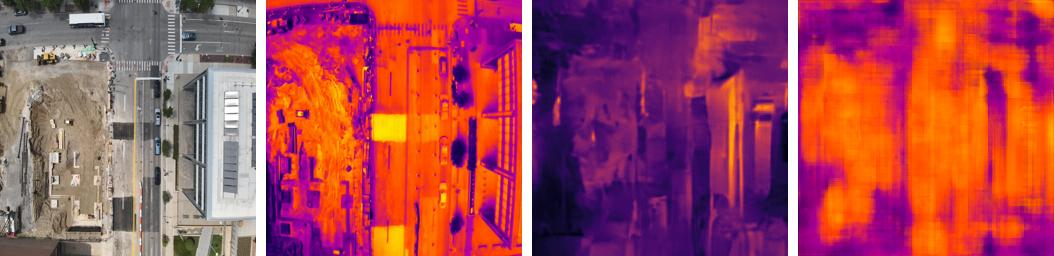

148.JPG:  RGB  |  Ground Truth  |  Baseline  |  Refined v2


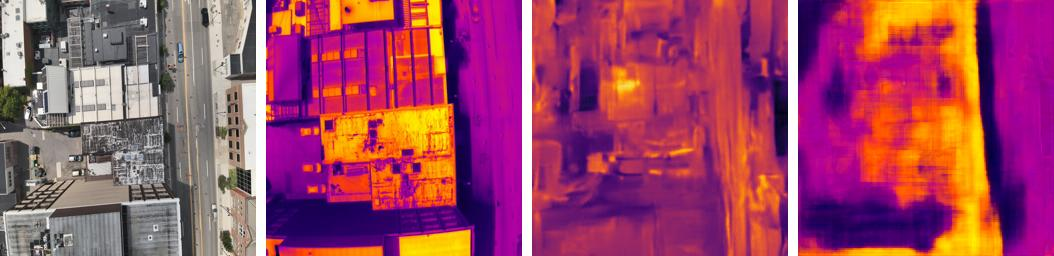

198.JPG:  RGB  |  Ground Truth  |  Baseline  |  Refined v2


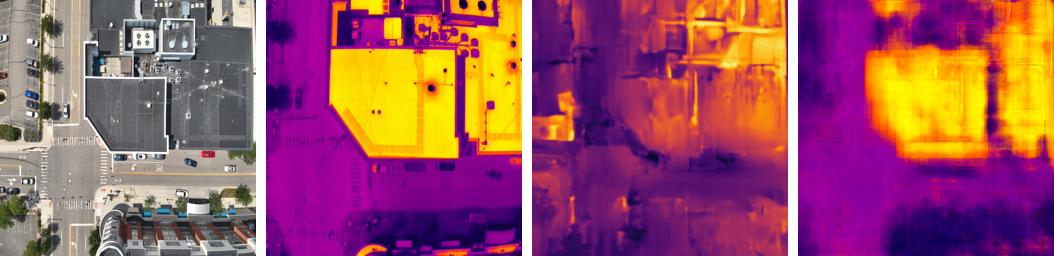

297.JPG:  RGB  |  Ground Truth  |  Baseline  |  Refined v2


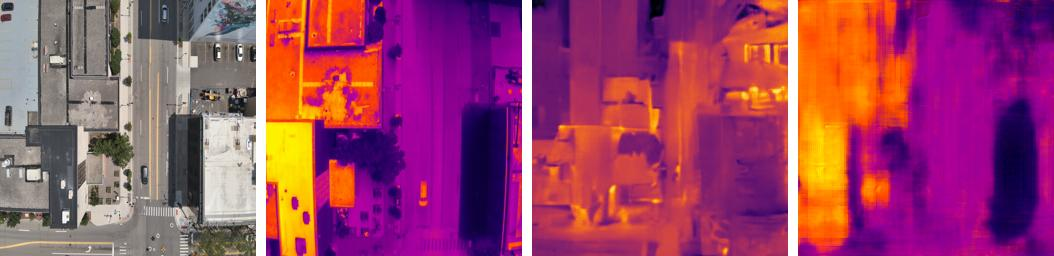

396.JPG:  RGB  |  Ground Truth  |  Baseline  |  Refined v2


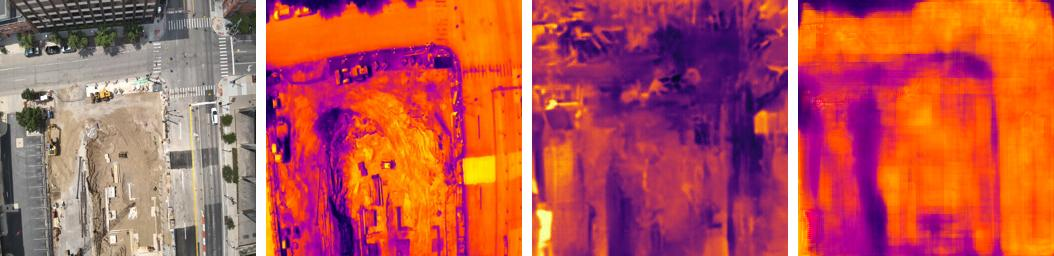

In [9]:
vis_dataset = HeatDatasetV2(TRAIN_RGB_DIR, TRAIN_THERMAL_DIR, BASELINE_TRAIN)

for idx in [0, 50, 100, 200, 300]:
    if idx >= len(vis_dataset):
        continue
    rgb, pred, w, a, gt, fname = vis_dataset[idx]

    with torch.no_grad():
        refined = model(
            rgb.unsqueeze(0).to(device), pred.unsqueeze(0).to(device),
            w.unsqueeze(0).to(device), a.unsqueeze(0).to(device)
        )
        baseline = apply_inferno_tensor(pred.unsqueeze(0).to(device))

    rgb_pil = to_pil_image(rgb)
    gt_pil = to_pil_image(gt)
    base_pil = to_pil_image(baseline[0].cpu())
    ref_pil = to_pil_image(refined[0].cpu())

    gap = 10
    combined = Image.new('RGB', (256*4 + gap*3, 256), (255,255,255))
    combined.paste(rgb_pil, (0, 0))
    combined.paste(gt_pil, (256+gap, 0))
    combined.paste(base_pil, (512+gap*2, 0))
    combined.paste(ref_pil, (768+gap*3, 0))
    combined.save(str(VIS_DIR / f'compare_{fname}'))

    print(f'{fname}:  RGB  |  Ground Truth  |  Baseline  |  Refined v2')
    display(IPImage(filename=str(VIS_DIR / f'compare_{fname}')))

## Cell 9: Generate Test Predictions

In [10]:
test_dataset = HeatDatasetV2(TEST_RGB_DIR, None, BASELINE_TEST, is_test=True)
test_dataset.w_mean = eval_dataset.w_mean
test_dataset.w_std = eval_dataset.w_std

test_loader = DataLoader(test_dataset, batch_size=4, shuffle=False, num_workers=2)

print(f'Generating {len(test_dataset)} test predictions...')
count = 0
with torch.no_grad():
    for batch in test_loader:
        rgb, pred, w, a, fnames = batch
        rgb, pred, w, a = rgb.to(device), pred.to(device), w.to(device), a.to(device)
        refined = model(rgb, pred, w, a)
        for i, fname in enumerate(fnames):
            to_pil_image(refined[i].cpu()).save(str(OUTPUT_DIR / fname))
            count += 1
        if count % 40 == 0:
            print(f'  [{count}/{len(test_dataset)}]')

print(f'\nDone! {count} predictions saved to {OUTPUT_DIR}')
print('\n★ These are your submission files!')

Generating 202 test predictions...
  [40/202]
  [80/202]
  [120/202]
  [160/202]
  [200/202]

Done! 202 predictions saved to /home/avaithinathanaso/AI_Heat_Resilience_Hackathon_Resources/AI_Heat_Resilience_Hackathon_Resources/ThermalGen/test_predictions_v2_nb

★ These are your submission files!


## Cell 10: Zip for Download

In [11]:
import zipfile

zip_path = TGEN / 'test_predictions_v2_nb.zip'
with zipfile.ZipFile(zip_path, 'w', zipfile.ZIP_DEFLATED) as zf:
    for f in sorted(os.listdir(OUTPUT_DIR)):
        if f.upper().endswith('.JPG'):
            zf.write(OUTPUT_DIR / f, f)

print(f'Zipped: {zip_path}')
print(f'Size: {os.path.getsize(zip_path) / 1e6:.1f} MB')

from IPython.display import FileLink
FileLink(str(zip_path))

Zipped: /home/avaithinathanaso/AI_Heat_Resilience_Hackathon_Resources/AI_Heat_Resilience_Hackathon_Resources/ThermalGen/test_predictions_v2_nb.zip
Size: 1.7 MB


/home/avaithinathanaso/AI_Heat_Resilience_Hackathon_Resources/AI_Heat_Resilience_Hackathon_Resources/ThermalGen/test_predictions_v2_nb.zip